# Generate Conditional Random Field (CRF) 
The CRF field contains:
1. prior information using SLE inversion (done first)
2. Apply geostatistic to analysis the statistics paramters
3. Conditional point and value sampling  

In [1]:
import os
import numpy as np
import pandas as pd
import gstools as gs
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from utilies import *

In [2]:
def plot_3d_isosurfaces(df_cor, col_name, iso_num, iso_range, title):
    """
    Parameters:
    -----------
    df_cor : pandas.DataFrame
        A DataFrame containing the 3D coordinates and the corresponding scalar values for plotting.
        Expected columns: ['x', 'y', 'z', col_name]

    col_name : str
        The name of the column in `df_cor` to be used for isosurface plotting.

    iso_num : int
        The number of isosurfaces to be plotted.

    iso_range : list or tuple of float
        The value range for the isosurfaces. Should be specified as [min_value, max_value].

    title : str
        The title of the figure to be displayed.
    """

    value = df_cor[col_name].values
    iso_min, iso_max = iso_range

    fig = go.Figure()

    fig.add_trace(go.Isosurface(
        x=df_cor['x'].values,
        y=df_cor['y'].values,
        z=df_cor['z'].values,
        value=value,
        isomin=iso_min,
        isomax=iso_max,
        surface_count=iso_num,
        colorscale='RdYlBu',   # 注意大小寫，建議用官方名稱
        showscale=True,
        opacity=0.4,
        caps=dict(x_show=False, y_show=False, z_show=False),

        colorbar=dict(
            title=dict(
                text=title,
                font=dict(size=18, family='Times New Roman', color='black')
            ),
            thickness=30,
            x=0.9,
            len=1.0,
            tickfont=dict(size=16)
        ),
    ))

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            y=0.95,
            xanchor='center',
            font=dict(size=36, family='Times New Roman')
        ),
        autosize=True,
        width=750,
        height=600,
        margin=dict(l=10, r=10, t=50, b=10),

        scene=dict(
            camera=dict(
                eye=dict(x=1, y=2, z=1),
            ),
            xaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            yaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            zaxis=dict(
                gridcolor='lightgray',
                showbackground=True,
                showline=True,
                linecolor='black',
                linewidth=2,
                showticklabels=False,
            ),
            aspectmode='data'
        ),
        font=dict(family="Times New Roman", size=20),
    )

    return fig

In [37]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_all_contours(df, col_name, value_range, contour_num, figsize):
    """
    df: 包含 x, y, z 與目標欄位的 DataFrame
    col_name: 要畫 contour 的欄位名稱
    value_range: (zmin, zmax)
    contour_num: contour 數量
    figsize: (width, height)
    """

    # -------- 基本檢查 --------
    required_cols = {'x', 'y', 'z', col_name}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"df 缺少必要欄位: {missing}")

    all_z = sorted(df['z'].unique())
    z_values = [z for i, z in enumerate(all_z) if i % 2 == 0]   # 每隔一層取一層
    # z_values = all_z  # 如果要全部層都畫，改成這行

    z_min, z_max = value_range

    # 深度標題
    check_depth = ['126', '108', '90', '72', '54', '36']
    if len(check_depth) >= len(z_values):
        subplot_titles = [f"Depth = {d} cm" for d in check_depth[:len(z_values)]]
    else:
        subplot_titles = [f"z = {z}" for z in z_values]

    # -------- 建立井位資料 --------
    well_data = [
        ("Pie_1", 188.5, 71),
        ("Pie_2", 88.5, 131),
        ("Pie_3", 88.5, 251),
        ("Pie_4", 188.5, 311),
        ("Pie_5", 388.5, 311),
        ("Pie_6", 488.5, 251),
        ("Pie_7", 488.5, 131),
        ("Pie_8", 388.5, 71),

        ("Inj_1", 288.5, 71),
        ("Inj_2", 88.5, 71),
        ("Inj_3", 88.5, 191),
        ("Inj_4", 88.5, 311),
        ("Inj_5", 288.5, 311),
        ("Inj_6", 488.5, 311),
        ("Inj_7", 488.5, 191),
        ("Inj_8", 488.5, 71),
    ]
    well_df = pd.DataFrame(well_data, columns=["name", "x", "y"])

    # 如果 contour 圖的座標是公尺，而井位目前是 cm，請轉成 m
    # well_df["x"] = well_df["x"] / 10
    # well_df["y"] = well_df["y"] / 10

    # 分類不同井位
    pie_df = well_df[well_df["name"].str.startswith("Pie")]
    inj_df = well_df[well_df["name"].str.startswith("Inj")]

    # -------- 建立子圖 --------
    fig = make_subplots(
        rows=len(z_values),
        cols=1,
        subplot_titles=subplot_titles,
        vertical_spacing=0.02,
        shared_xaxes=True
    )

    # -------- 逐層畫 contour --------
    for i, z in enumerate(z_values):
        df_slice = df[df["z"] == z].copy()

        if df_slice.empty:
            print(f"Warning: z={z} 沒有資料，跳過")
            continue

        pivot_df = df_slice.pivot_table(index="y", columns="x", values=col_name)

        xi = pivot_df.columns.values
        yi = pivot_df.index.values
        zi = pivot_df.values

        # contour
        fig.add_trace(
            go.Contour(
                x=xi,
                y=yi,
                z=zi,
                zmin=z_min,
                zmax=z_max,
                colorscale='RdYlBu',
                opacity=0.8,
                ncontours=contour_num,
                line=dict(width=0.25, color='#333333'),
                coloraxis="coloraxis",
                showscale=False
            ),
            row=i+1, col=1
        )

        # Pie 井位
        fig.add_trace(
            go.Scatter(
                x=pie_df["x"],
                y=pie_df["y"],
                mode='markers+text',
                text=pie_df["name"],
                textposition='top right',
                textfont=dict(family="Times New Roman", size=11, color="blue"),
                marker=dict(size=7, color='blue', symbol='circle'),
                name='Pie well',
                showlegend=(i == 0)   # 只在第一張子圖顯示 legend
            ),
            row=i+1, col=1
        )

        # Inj 井位
        fig.add_trace(
            go.Scatter(
                x=inj_df["x"],
                y=inj_df["y"],
                mode='markers+text',
                text=inj_df["name"],
                textposition='top right',
                textfont=dict(family="Times New Roman", size=11, color="red"),
                marker=dict(size=7, color='red', symbol='square'),
                name='Injection well',
                showlegend=(i == 0)
            ),
            row=i+1, col=1
        )

    # -------- 調整 subplot 標題位置 --------
    for i in range(len(fig.layout.annotations)):
        y_ref_str = 'y domain' if i == 0 else f'y{i+1} domain'
        fig.layout.annotations[i].update(
            x=0.9,
            yref=y_ref_str,
            y=0.03,
            xanchor='right',
            yanchor='bottom',
            font=dict(size=14, family="Times New Roman", color="black"),
            bgcolor="rgba(255,255,255,0.7)"
        )

    # -------- 全域 layout --------
    fig.update_layout(
        height=figsize[1],
        width=figsize[0],
        template="plotly_white",
        font=dict(family="Times New Roman"),
        margin=dict(l=20, r=20, t=20, b=60),

        coloraxis=dict(
            colorscale='RdYlBu',
            cmin=z_min,
            cmax=z_max,
            colorbar=dict(
                title=dict(
                    text='lnK',
                    side='top'
                ),
                orientation='h',
                thickness=18,
                len=0.7,
                x=0.5,
                xanchor='center',
                y=-0.06,
                yanchor='top',
                outlinewidth=0,
                tickfont=dict(family="Times New Roman", size=12)
            )
        ),

        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.02,
            yanchor="bottom"
        )
    )

    # -------- 統一座標軸字體 --------
    fig.update_xaxes(
        tickfont=dict(family="Times New Roman", size=12),
        title_font=dict(family="Times New Roman", size=16)
    )
    fig.update_yaxes(
        tickfont=dict(family="Times New Roman", size=12),
        title_font=dict(family="Times New Roman", size=16)
    )

    # 中間那張圖加 Y 軸標題
    middle_row = (len(z_values) // 2) + 1
    fig.update_yaxes(
        title_text="Y (m)",
        row=middle_row, col=1
    )

    # 清空所有 X 軸標題
    for r in range(1, len(z_values)+1):
        fig.update_xaxes(title_text="", row=r, col=1)

    # 最後一張圖加 X 軸標題
    fig.update_xaxes(
        title_text="X (m)",
        row=len(z_values), col=1
    )

    fig.show()
    return fig

In [76]:
# Import prior K
iter = 16
file_name = "inverse/O-kestimate_prior.dat"
df_mean, df_var = parse_estimation(file_name, dim =3)

df_prior = df_mean[['x', 'y', 'z', f'iter_{iter}']].copy()
df_prior['log_K'] = np.log(df_prior[f'iter_{iter}'].values)

df_prior_core = df_prior[
    (df_prior['x'] >= 132) & (df_prior['x'] <= 445) &
    (df_prior['y'] >= 96) & (df_prior['y'] <= 286) &
    (df_prior['z'] >= 95) & (df_prior['z'] <= 195)
]


<Axes: >

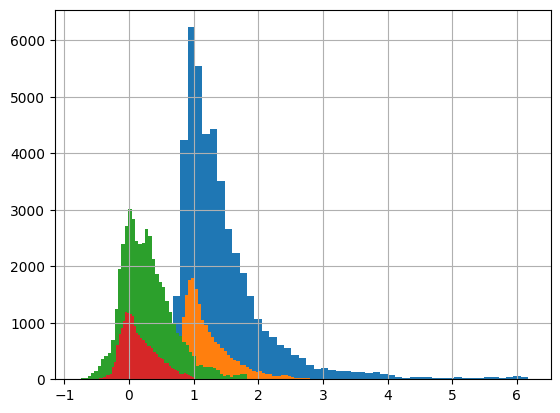

In [ ]:
df_prior[f'iter_{iter}'].hist(bins = 50)
df_prior_core[f'iter_{iter}'].hist(bins = 50)


np.log(df_prior[f'iter_{iter}']).hist(bins = 50)
np.log(df_prior_core[f'iter_{iter}']).hist(bins = 50)

### 3D plot for priro information

In [74]:
plot_3d_isosurfaces(df_prior_core, f'iter_{iter}', 8, [1, 2], 'lnK')
# plot_3d_isosurfaces(df_prior_core, 'log_K', 8, [-1, 1], 'lnK')

### 2D slice contour plot prior information

In [75]:
fig = plot_all_contours(df_prior_core, f'iter_{iter}', [1, 2], 15, (600, 3600))
# fig = plot_all_contours(df_prior, 'log_K', [-1, 1], 15, (600, 4800))

## Geostatistics analysis

In [78]:
xg, yg, zg, inter_inK = interpolate_3d(df_prior_core, value_col=f'iter_{iter}', grid_size=[120, 60, 60], method="linear")

-------------- Variogram Fitting for X Direction --------------
Model: Gaussian;  Pseudo r2 = 0.983
Gaussian(dim=3, var=0.0976, len_scale=58.9, nugget=0.00156)
Model: Exponential;  Pseudo r2 = 0.942
Exponential(dim=3, var=0.129, len_scale=1.03e+02)
Model: Stable;  Pseudo r2 = 0.983
Stable(dim=3, var=0.098, len_scale=66.4, nugget=0.00128, alpha=1.97)
Model: Circular;  Pseudo r2 = 0.966
Circular(dim=3, var=0.0995, len_scale=1.33e+02)
Model: Spherical;  Pseudo r2 = 0.966
Spherical(dim=3, var=0.1, len_scale=1.52e+02, nugget=5.37e-08)


<Figure size 1000x600 with 0 Axes>

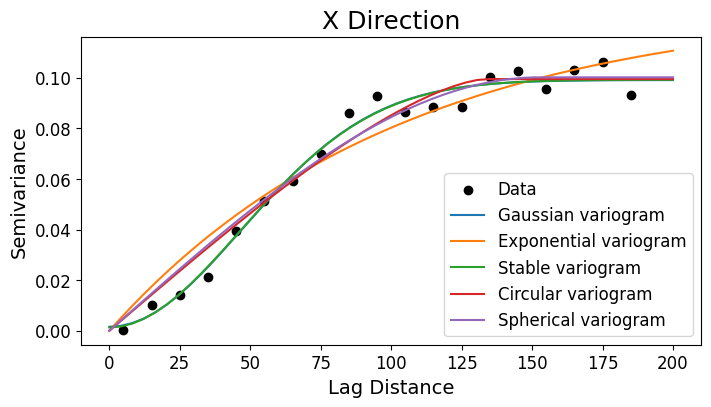

-------------- Variogram Fitting for Y Direction --------------
Model: Gaussian;  Pseudo r2 = 0.970
Gaussian(dim=3, var=0.0802, len_scale=37.5, nugget=0.00198)
Model: Exponential;  Pseudo r2 = 0.956
Exponential(dim=3, var=0.223, len_scale=1.71e+02)
Model: Stable;  Pseudo r2 = 0.973
Stable(dim=3, var=0.0879, len_scale=45.4, alpha=1.66)
Model: Circular;  Pseudo r2 = 0.960
Circular(dim=3, var=0.0878, len_scale=92.0, nugget=5.05e-07)
Model: Spherical;  Pseudo r2 = 0.960
Spherical(dim=3, var=0.0951, len_scale=1.16e+02)


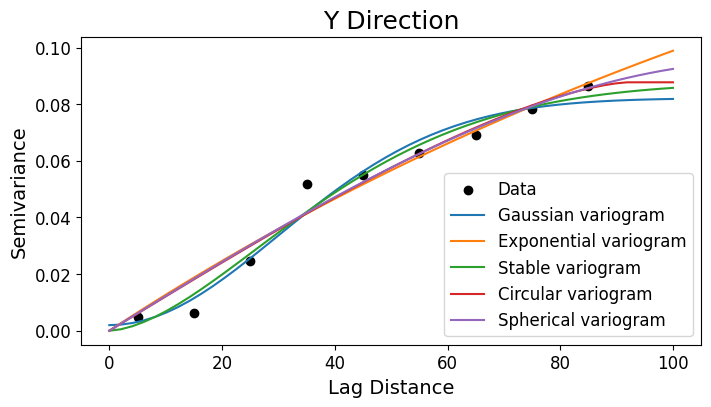

-------------- Variogram Fitting for Z Direction --------------
Model: Gaussian;  Pseudo r2 = 0.975
Gaussian(dim=3, var=0.509, len_scale=1.05e+02, nugget=0.00776)
Model: Exponential;  Pseudo r2 = 0.918
Exponential(dim=3, var=6.44e+02, len_scale=2.95e+05)
Model: Stable;  Pseudo r2 = 0.979
Stable(dim=3, var=2.92e+02, len_scale=8.86e+03, nugget=0.00032, alpha=1.55)
Model: Circular;  Pseudo r2 = 0.918
Circular(dim=3, var=17.5, len_scale=1.02e+04)
Model: Spherical;  Pseudo r2 = 0.918
Spherical(dim=3, var=38.9, len_scale=2.67e+04)


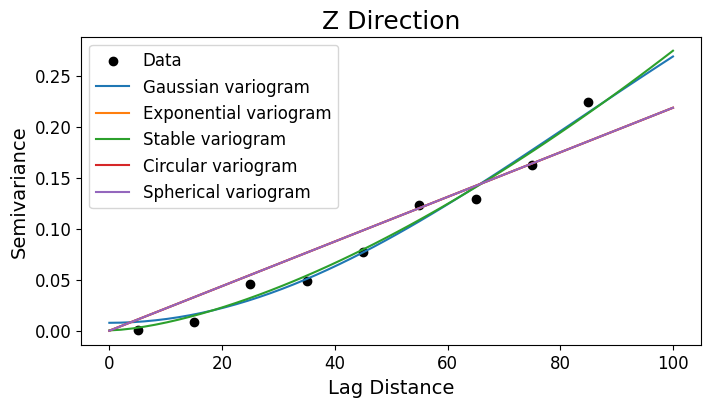

In [84]:
df_geo = pd.DataFrame({'x': xg.flatten(),
                       'y': yg.flatten(),
                       'z': zg.flatten(),
                       'ln_mean': inter_inK.flatten()})
# plot_3d_isosurfaces(df_geo, 'ln_mean', 5, [-10, -7], 'SLE lnK interpolation')

bins_x = np.arange(0,  200 ,  10)
bins_y = np.arange(0,  100,   10)
bins_z = np.arange(0,  100,   10)

plt.figure(figsize = (10, 6))
variogram_test(coordinate = (xg,yg,zg), value=df_geo['ln_mean'], bins= bins_x, direction='X', max_dis = 200)
plt.show()
variogram_test(coordinate = (xg,yg,zg), value=df_geo['ln_mean'], bins= bins_y, direction='Y', max_dis = 100)
plt.show()
variogram_test(coordinate = (xg,yg,zg), value=df_geo['ln_mean'], bins= bins_z, direction='Z', max_dis = 100)
plt.show()